In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

print("Path to dataset files:", path)

/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 15.8k/15.8k [00:00<00:00, 10.6MB/s]

Extracting files...
Path to dataset files: /Users/abdullahalhossain/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [10]:
import pandas as pd

df=pd.read_csv("./dataset_Teenage/Teen_Mental_Health_Dataset.csv")

print(df.head(),"\n\n\n")
print(df.size)

print("Academic Performence in TOTAL (MAX/MIN): ",df["Academic_Performance"].max(),"/",df["Academic_Performance"].min())

   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2              2   

In [8]:
positive = df.loc[df["depression_label"]==1,['age','daily_social_media_hours','depression_label']]

print(len(positive))
display(positive)



31


,age,daily_social_media_hours,depression_label
89,18,6.2,1
163,15,7.8,1
300,13,7.8,1
321,15,5.1,1
384,13,7.5,1
581,13,7.2,1
585,19,5.2,1
588,15,5.2,1
591,19,7.7,1
600,16,7.4,1


In [17]:
# 1. Calculate means for numbers only
comparison = df.groupby('depression_label').mean(numeric_only=True)

# 2. Calculate the percentage difference
diff_pct = ((comparison.loc[1] - comparison.loc[0]) / comparison.loc[0]) * 100
diff_pct2 = ((comparison.loc[0] - comparison.loc[1]) / comparison.loc[0]) * 100

print("--- Feature Comparison (Depression vs. Non-Depression) ---")
print(diff_pct.sort_values(ascending=False))
print("\n\n")
print("--- Feature Comparison (Non-Depression vs. Depression) ---")
print(diff_pct2.sort_values(ascending=False))

--- Feature Comparison (Depression vs. Non-Depression) ---
stress_level                58.125720
anxiety_level               54.971277
daily_social_media_hours    50.026277
age                          0.877844
academic_performance         0.175096
screen_time_before_sleep    -4.277001
addiction_level             -4.466501
physical_activity           -6.352767
sleep_hours                -26.683768
dtype: float64



--- Feature Comparison (Non-Depression vs. Depression) ---
sleep_hours                 26.683768
physical_activity            6.352767
addiction_level              4.466501
screen_time_before_sleep     4.277001
academic_performance        -0.175096
age                         -0.877844
daily_social_media_hours   -50.026277
anxiety_level              -54.971277
stress_level               -58.125720
dtype: float64


In [18]:
# Drop the columns that don't help distinguish between the groups
columns_to_drop = ['academic_performance', 'age']
df_cleaned = df.drop(columns=columns_to_drop)

# Verify the new shape
print(f"Original columns: {df.shape[1]}")
print(f"Cleaned columns: {df_cleaned.shape[1]}")

# Now your model will only focus on the 'Strong' features

Original columns: 13
Cleaned columns: 11


In [22]:
positive2 = df.loc[df["depression_label"]==1,['age','sleep_hours','depression_label']]

display(positive2)

max_SL=positive2['sleep_hours'].max()
min_SL=positive2['sleep_hours'].min()
print()
print()
print("Max and MIN SLEEP for depressed: ", max_SL,min_SL,sep=',')

,age,sleep_hours,depression_label
89,18,4.1,1
163,15,5.3,1
300,13,5.0,1
321,15,4.1,1
384,13,4.8,1
581,13,4.2,1
585,19,4.3,1
588,15,5.6,1
591,19,4.2,1
600,16,5.5,1




Max and MIN SLEEP for depressed: ,5.8,4.1


In [23]:
# Check Social Media hours for the same 31 people
positive_social = df.loc[df["depression_label"] == 1, 'daily_social_media_hours']

print(f"Social Media Window for Depressed: {positive_social.min()} to {positive_social.max()} hours")

Social Media Window for Depressed: 5.1 to 8.0 hours


In [24]:

false_positives = df[
    (df['depression_label'] == 0) & 
    (df['sleep_hours'] <= 5.8) & 
    (df['daily_social_media_hours'] >= 5.1)
]

print(f"Number of Healthy people in the 'Risk Window': {len(false_positives)}")

Number of Healthy people in the 'Risk Window': 158


In [25]:
print("Risk Individuals:",len(positive2)+len(false_positives))

Risk Individuals: 189


In [33]:
filter2=df.loc[ (df["depression_label"]==0) &  (df['sleep_hours'] <= 5.8) & 
    (df['daily_social_media_hours'] >= 5.1), ["physical_activity","academic_performance"]]
display(filter2)
print(len(filter2))

max_academic="max_academic_performance: ", (filter2['academic_performance'].max())
min_academic="min_academic_performance: ", (filter2['academic_performance'].min())
print(max_academic,min_academic,sep='\n')

,physical_activity,academic_performance
5,0.6,2.63
10,1.2,3.16
13,1.3,3.29
22,1.2,3.69
30,1.1,2.67
...,...,...
1162,1.0,2.34
1164,0.0,3.30
1175,0.5,2.27
1177,0.5,2.13


158
('max_academic_performance: ', np.float64(4.0))
('min_academic_performance: ', np.float64(2.03))


In [35]:
print("Academic Performence in TOTAL (MAX/MIN): ",df["academic_performance"].max(),"/",df["academic_performance"].min())

Academic Performence in TOTAL (MAX/MIN):  4.0 / 2.0


In [36]:
# Compare the "Hidden" differences
cols_to_check = ['stress_level', 'anxiety_level', 'platform_usage']

# 1. Stats for the 31 Depressed
depressed_profile = df.loc[df['depression_label'] == 1, cols_to_check]

# 2. Stats for the 158 Resilient
resilient_profile = df.loc[
    (df["depression_label"] == 0) & 
    (df['sleep_hours'] <= 5.8) & 
    (df['daily_social_media_hours'] >= 5.1), 
    cols_to_check
]

print("--- DEPRESSED PROFILE (31) ---")
print(depressed_profile.describe().loc[['mean', 'min', 'max']])
print("\n--- RESILIENT PROFILE (158) ---")
print(resilient_profile.describe().loc[['mean', 'min', 'max']])

--- DEPRESSED PROFILE (31) ---
      stress_level  anxiety_level
mean      8.483871       8.612903
min       7.000000       7.000000
max      10.000000      10.000000

--- RESILIENT PROFILE (158) ---
      stress_level  anxiety_level
mean      4.778481        5.06962
min       1.000000        1.00000
max      10.000000       10.00000


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Selecting the high-signal features we identified
features = ['stress_level', 'anxiety_level', 'sleep_hours', 'daily_social_media_hours', 'physical_activity']
X = df[features]
y = df['depression_label']

# Splitting the data
# We use stratify=y to ensure those 31 people are split proportionally 
# between the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [39]:


# 1. Feature Engineering: Hard-coding your Scraping Discoveries
# We create 'Binary Flags' for the thresholds you found
df['is_sleep_deprived'] = (df['sleep_hours'] <= 5.8).astype(int)
df['is_high_stress'] = (df['stress_level'] >= 7).astype(int)
df['is_high_social_media'] = (df['daily_social_media_hours'] >= 5.1).astype(int)

# 2. Selecting Features
# We include your engineered signals + the raw numerical data
# We exclude 'academic_performance' and 'age' as they were 'noisy'
features = [
    'stress_level', 'anxiety_level', 'sleep_hours', 
    'daily_social_media_hours', 'physical_activity',
    'is_sleep_deprived', 'is_high_stress', 'is_high_social_media'
]

X = df[features]
y = df['depression_label']



In [40]:


# 3. Stratified Split
# Essential because we only have 31 positive cases (label=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [41]:
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    class_weight='balanced_subsample', 
    random_state=42
)
model.fit(X_train_scaled, y_train)

# 6. Evaluation
y_pred = model.predict(X_test_scaled)

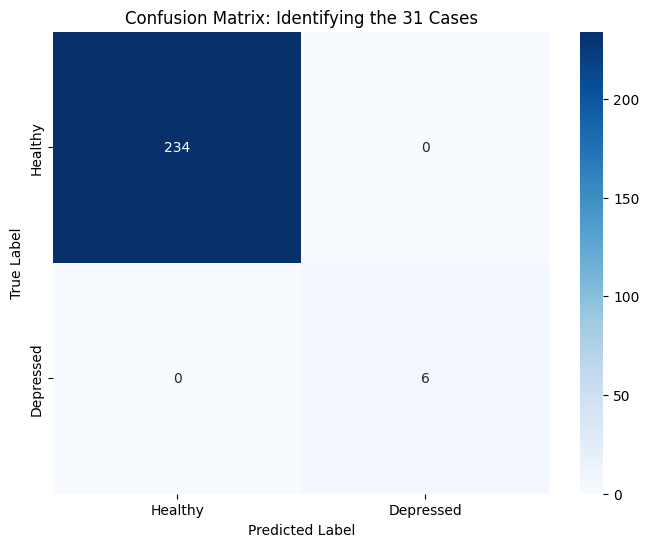

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure
plt.figure(figsize=(8, 6))

# Generate the heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Depressed'], 
            yticklabels=['Healthy', 'Depressed'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Identifying the 31 Cases')
plt.show()

In [45]:
importances = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- FEATURE IMPORTANCE ---")
print(importances)


--- FEATURE IMPORTANCE ---
                    feature  importance
2               sleep_hours    0.208436
0              stress_level    0.166515
1             anxiety_level    0.157716
5         is_sleep_deprived    0.150860
6            is_high_stress    0.125808
3  daily_social_media_hours    0.098413
7      is_high_social_media    0.087886
4         physical_activity    0.004365


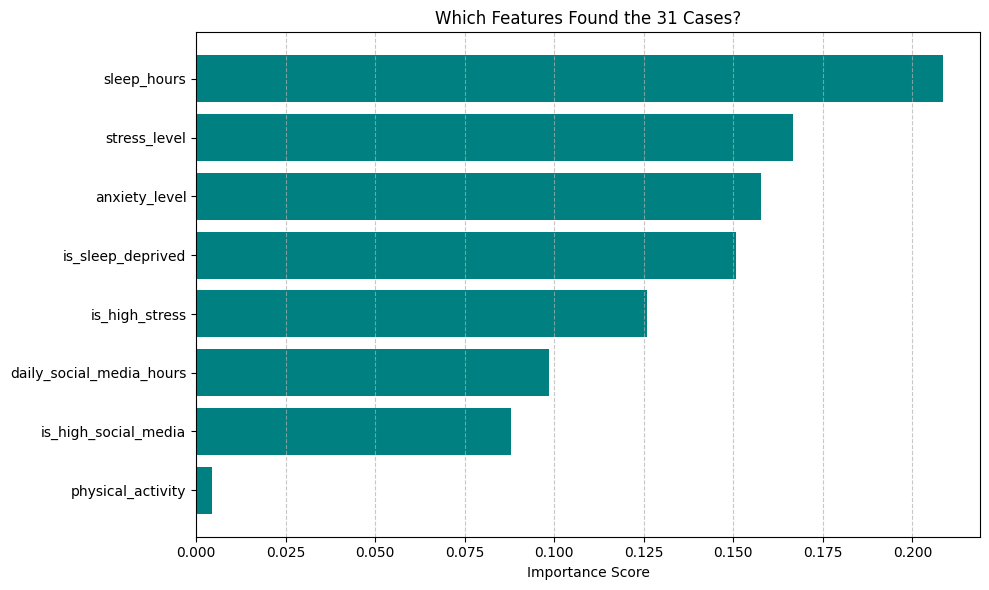

In [46]:
# Sort the importances
importances = importances.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importances['feature'], importances['importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Which Features Found the 31 Cases?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

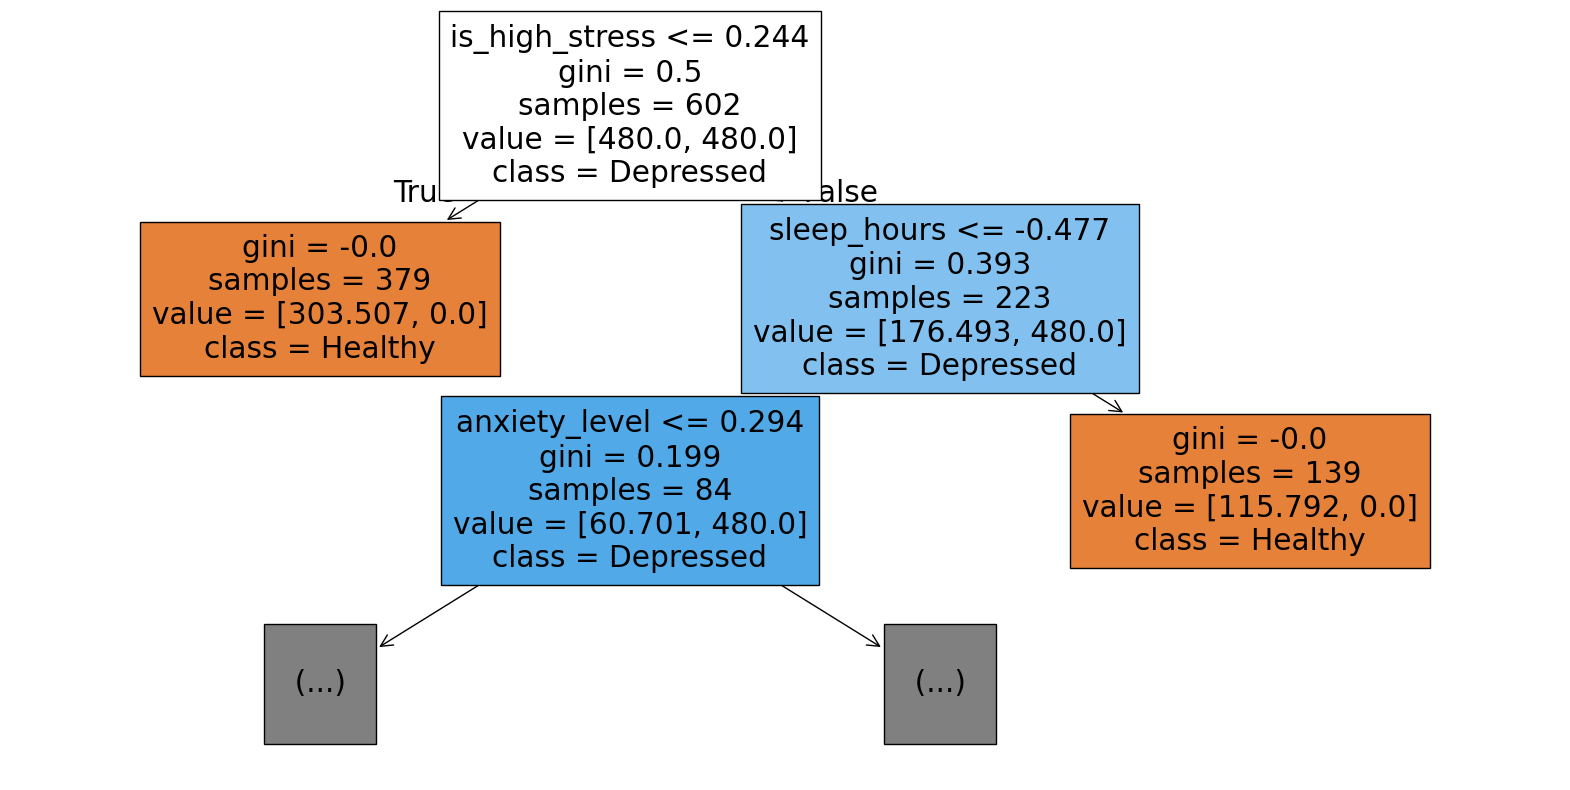

In [47]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
# Plotting the first tree in the forest
plot_tree(model.estimators_[0], 
          feature_names=features, 
          class_names=['Healthy', 'Depressed'], 
          filled=True, max_depth=2) # Only show top 2 levels for clarity
plt.show()

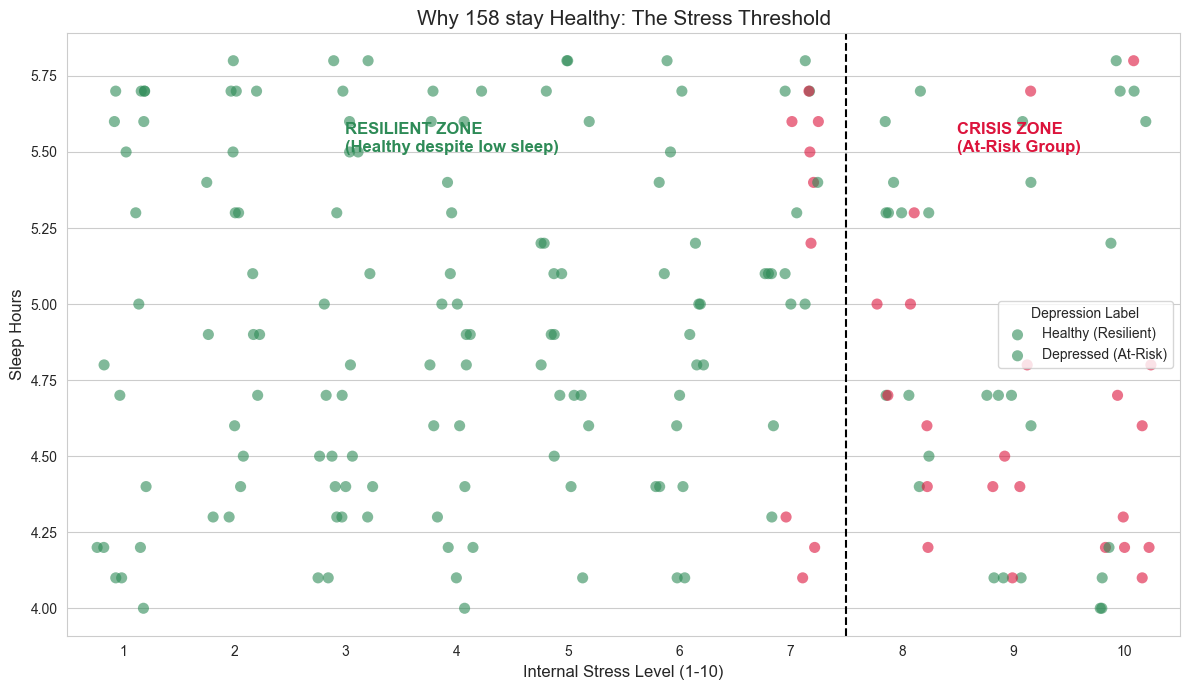

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the data to only show people in your "Risk Window" 
# (Sleep <= 5.8 and Social Media >= 5.1)
risk_window_df = df[(df['sleep_hours'] <= 5.8) & (df['daily_social_media_hours'] >= 5.1)]

# 2. Set up the visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 3. Scatter plot to show the individuals
# We use 'jitter' to make sure dots don't stack perfectly on top of each other
sns.stripplot(data=risk_window_df, x='stress_level', y='sleep_hours', 
              hue='depression_label', palette={0: 'seagreen', 1: 'crimson'},
              alpha=0.6, size=8, jitter=0.25)

# 4. Draw the "Breaking Point" line at Stress Level 7
plt.axvline(x=6.5, color='black', linestyle='--', label='The Break Point (Stress Level 7)')

# 5. Labeling the "Shield" and the "Crisis"
plt.text(2, 5.5, "RESILIENT ZONE\n(Healthy despite low sleep)", fontsize=12, color='seagreen', fontweight='bold')
plt.text(7.5, 5.5, "CRISIS ZONE\n(At-Risk Group)", fontsize=12, color='crimson', fontweight='bold')

plt.title("Why 158 stay Healthy: The Stress Threshold", fontsize=15)
plt.xlabel("Internal Stress Level (1-10)", fontsize=12)
plt.ylabel("Sleep Hours", fontsize=12)
plt.legend(title="Depression Label", labels=['Healthy (Resilient)', 'Depressed (At-Risk)'])

plt.tight_layout()
plt.show()

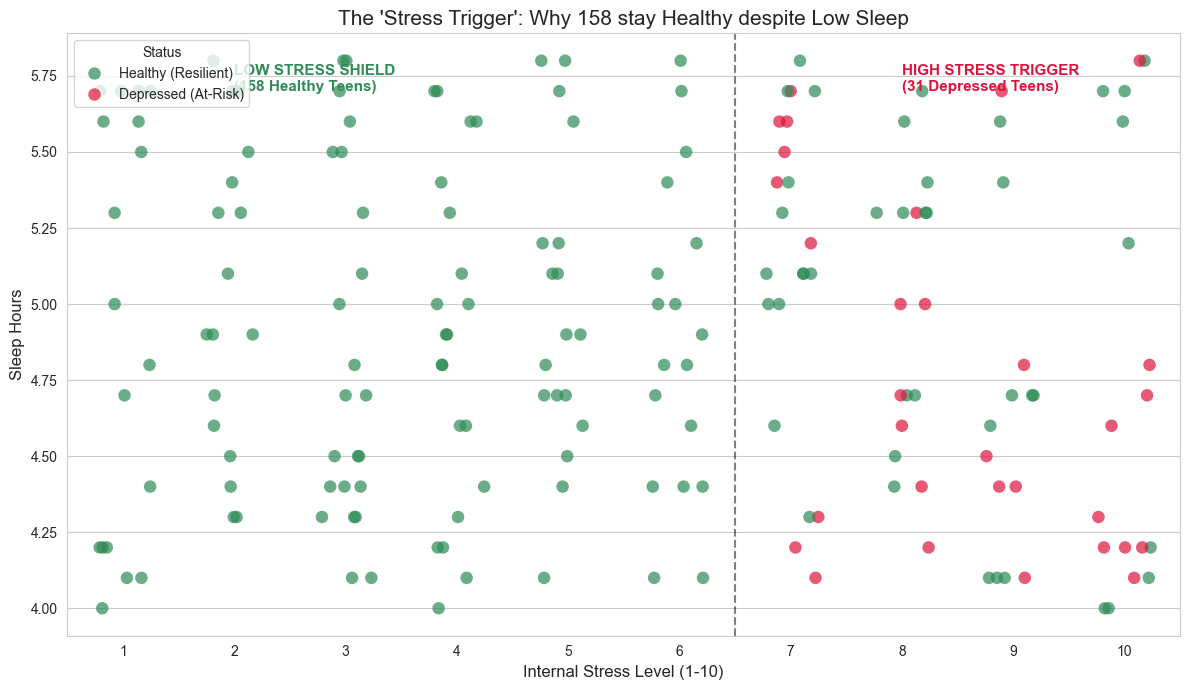

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the data to only show people in your "Risk Window"
risk_window_df = df[(df['sleep_hours'] <= 5.8) & (df['daily_social_media_hours'] >= 5.1)].copy()

# 2. Set up the visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 3. Scatter plot 
# We explicitly map the colors using the 'palette' argument
scatter = sns.stripplot(data=risk_window_df, x='stress_level', y='sleep_hours', 
                        hue='depression_label', palette={0: 'seagreen', 1: 'crimson'},
                        alpha=0.7, size=9, jitter=0.25)

# 4. Draw the "Breaking Point" line at Stress Level 7
plt.axvline(x=5.5, color='black', linestyle='--', alpha=0.5) # x=5.5 centers the line between 6 and 7 on the axis

# 5. Fix the Legend Colors
# This tells matplotlib to look at the actual plot handles
handles, _ = scatter.get_legend_handles_labels()
plt.legend(handles, ['Healthy (Resilient)', 'Depressed (At-Risk)'], title="Status", loc='upper left')

# 6. Annotations for the "Shield" and the "Crisis"
plt.text(1, 5.7, "LOW STRESS SHIELD\n(158 Healthy Teens)", fontsize=11, color='seagreen', fontweight='bold')
plt.text(7, 5.7, "HIGH STRESS TRIGGER\n(31 Depressed Teens)", fontsize=11, color='crimson', fontweight='bold')

plt.title("The 'Stress Trigger': Why 158 stay Healthy despite Low Sleep", fontsize=15)
plt.xlabel("Internal Stress Level (1-10)", fontsize=12)
plt.ylabel("Sleep Hours", fontsize=12)

plt.tight_layout()
plt.show()